In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Uncomment the following lines if this your first time running the code. It will download the necessary NLTK resources
# nltk.download('wordnet')
# nltk.download('punkt')
# nltk.download('punkt_tab')

### OKCupid Profiles

**WARNING**: OKcupid dataset not in repo. You will need to download it and put it into the `data` folder manually. 

**Source:** [OkCupid Profiles](https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles)

In [9]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR.parent / "data" / "okcupid_profiles.csv"

if DATA_PATH.exists():
    okcupid = pd.read_csv(DATA_PATH)
else:
    print(f"ERROR: File not found at {DATA_PATH}")

print(okcupid.columns)
print('===========')
print(okcupid.describe())

Index(['age', 'status', 'sex', 'orientation', 'body_type', 'diet', 'drinks',
       'drugs', 'education', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'pets', 'religion', 'sign',
       'smokes', 'speaks', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4',
       'essay5', 'essay6', 'essay7', 'essay8', 'essay9'],
      dtype='str')
                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000


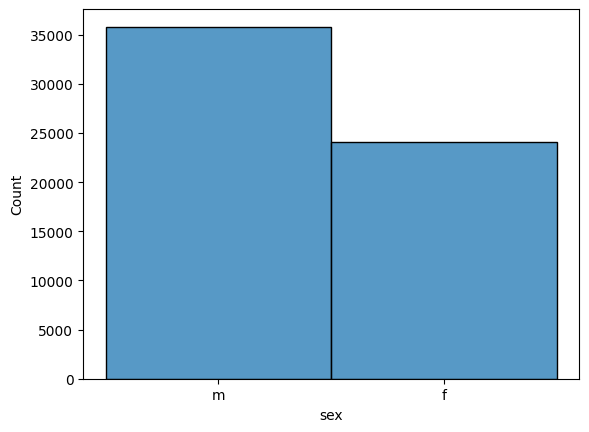

In [10]:
sns.histplot(okcupid['sex'])
plt.show()

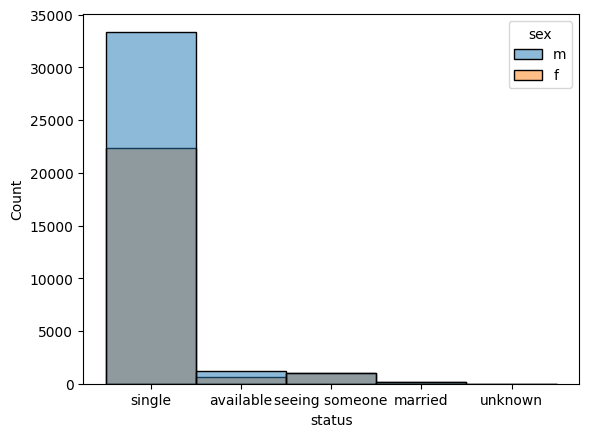

In [11]:
sns.histplot(data=okcupid, x='status', hue='sex')
plt.show()

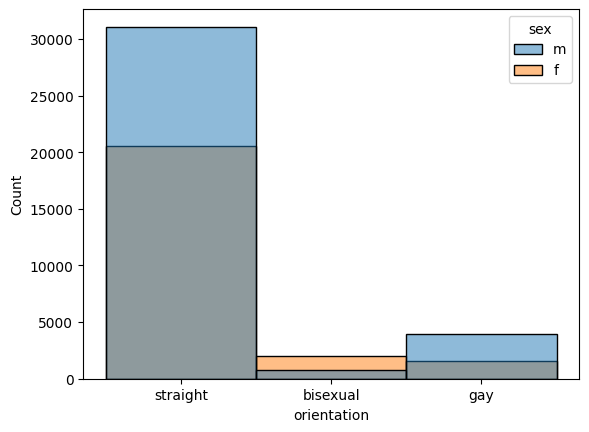

In [12]:
sns.histplot(data=okcupid, x='orientation', hue='sex')
plt.show()

3


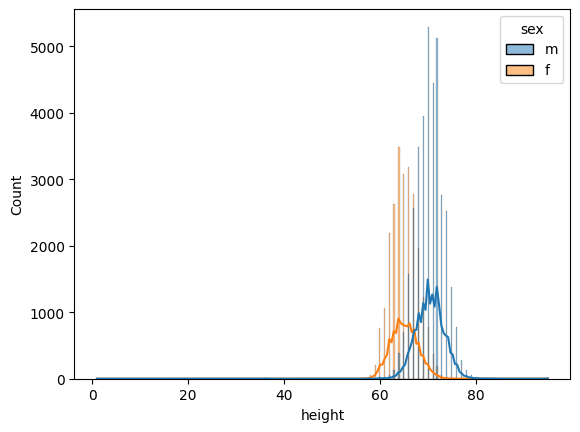

In [13]:
print(len(okcupid[okcupid.height.isna()]))
sns.histplot(data=okcupid, x='height', hue='sex', kde=True)
plt.show()

2985


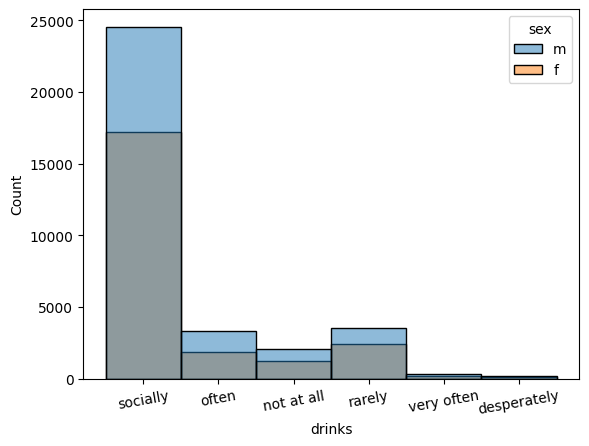

In [14]:
print(len(okcupid[okcupid.drinks.isna()]))
sns.histplot(data=okcupid, x='drinks', hue='sex')
plt.xticks(rotation=10)
plt.show()

5512


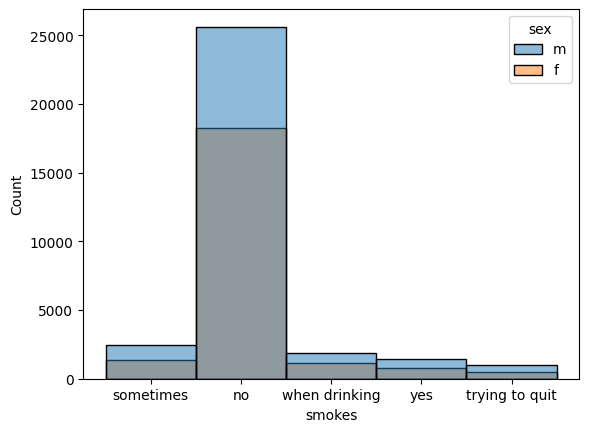

In [15]:
print(len(okcupid[okcupid.smokes.isna()]))
sns.histplot(data=okcupid, x='smokes', hue='sex')
plt.show()

24395


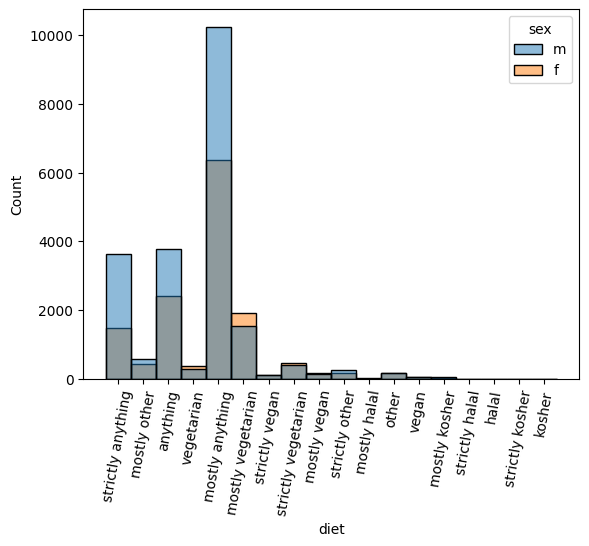

In [16]:
print(len(okcupid[okcupid.diet.isna()]))
sns.histplot(data=okcupid, x='diet', hue='sex')
plt.xticks(rotation=80)
plt.show()

In [17]:
cupid_text = okcupid.copy()

essay_columns = cupid_text.iloc[:,21:].columns
for col in essay_columns:
    cupid_text[col] = cupid_text[col].fillna(' ')

cupid_text["essay"] = (cupid_text["essay0"].str
                       .cat(cupid_text.iloc[:,22:].astype(str), sep=" "))

cupid_text = cupid_text.drop(cupid_text.iloc[:,21:-1], axis=1)

cupid_text["total words"] = cupid_text["essay"].str.split().str.len()

cupid_text['total words'].head()

0    450
1    268
2    856
3     75
4    105
Name: total words, dtype: int64

In [18]:
okcupid.sign.value_counts().head()

sign
gemini and it&rsquo;s fun to think about     1782
scorpio and it&rsquo;s fun to think about    1772
leo and it&rsquo;s fun to think about        1692
libra and it&rsquo;s fun to think about      1649
taurus and it&rsquo;s fun to think about     1640
Name: count, dtype: int64

In [19]:
okcupid[['height','income','job','last_online','location',
         'offspring','pets','religion','smokes','speaks']].head()

,height,income,job,last_online,location,offspring,pets,religion,smokes,speaks
0,75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california","doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english
1,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california","doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (..."
2,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",NaN,has cats,NaN,no,"english, french, c++"
3,71.0,20000,student,2012-06-28-14-22,"berkeley, california",doesn't want kids,likes cats,NaN,no,"english, german (poorly)"
4,66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",NaN,likes dogs and likes cats,NaN,no,english


In [20]:
okcupid.location.value_counts()

location
san francisco, california    31064
oakland, california           7214
berkeley, california          4212
san mateo, california         1331
palo alto, california         1064
                             ...  
denver, colorado                 1
seattle, washington              1
cincinnati, ohio                 1
phoenix, arizona                 1
rochester, michigan              1
Name: count, Length: 199, dtype: int64

In [21]:
okcupid.religion.value_counts().head()

religion
agnosticism                                 2724
other                                       2691
agnosticism but not too serious about it    2636
agnosticism and laughing about it           2496
catholicism but not too serious about it    2318
Name: count, dtype: int64

In [22]:
print(len(okcupid[okcupid.offspring.isna()]))
okcupid.offspring.value_counts().head()

35561


offspring
doesn't have kids                         7560
doesn't have kids, but might want them    3875
doesn't have kids, but wants them         3565
doesn't want kids                         2927
has kids                                  1883
Name: count, dtype: int64

### Separation of Columns

In [23]:
signs = ['aries','taurus','gemini','cancer','leo','virgo','libra',
         'scorpio','sagittarius','capricorn','aquarius','pisces']

opinions = ['fun to think about', 'matters a lot', 'but']

educ_status = ['graduated from', 'working on', 'dropped out']

schools = ['college/university', 'masters', 'two-year college',
           'high school', 'ph.d', 'law school', 'space camp',
           'med school']

pet_status = ['likes dogs', 'likes cats', 'dislikes dogs',
              'dislikes cats', 'has dogs', 'has cats']

religions = ['agnosticism','islam','hinduism','judaism','atheism',
             'christianity','other','buddhism','catholicism']

religion_attitude = ['not too serious', 'laughing about it',
                     'somewhat serious', 'very serious']

ethnicities = ['white','black','asian','hispanic / latin',
               'middle eastern','indian','pacific islander',
               'native american','other']

In [24]:
cupid_signs = cupid_text.copy()

cupid_signs.drugs = cupid_signs.drugs.fillna('never')
cupid_signs.drinks = cupid_signs.drinks.fillna('socially')
cupid_signs.smokes = cupid_signs.smokes.fillna('no')
cupid_signs.body_type = cupid_signs.body_type.fillna('average')
cupid_signs.height = cupid_signs.height.fillna(cupid_signs.height.median())
cupid_signs.offspring = cupid_signs.offspring.fillna(0)
cupid_signs.pets = cupid_signs.pets.fillna('neutral on dogs and neutral on cats')

In [25]:
for zodiac in signs:
    cupid_signs[zodiac] = (cupid_signs.sign.str.contains(zodiac))

for opinion in opinions:
    cupid_signs[opinion] = (cupid_signs.sign.str.contains(opinion))

for educ in educ_status:
    cupid_signs[educ] = (cupid_signs.education.str.contains(educ))

for school in schools:
    cupid_signs[school] = (cupid_signs.education.str.contains(school))

for pet in pet_status:
    cupid_signs[pet] = (cupid_signs.pets.str.contains(pet))

for rel in religions:
    cupid_signs[rel] = (cupid_signs.religion.str.contains(rel))

for attitude in religion_attitude:
    cupid_signs[attitude] = (cupid_signs.religion.str.contains(attitude))

cupid_signs.rename(columns={'other':'other religion'}, inplace=True)

for eth in ethnicities:
    cupid_signs[eth] = (cupid_signs.ethnicity.str.contains(eth))
    cupid_signs[eth] = pd.to_numeric(cupid_signs[eth], downcast='integer', errors='coerce')

In [26]:
cupid_signs.rename(columns={'but':'zodiac does not matter',
                            'matters a lot':'zodiac matters a lot',
                            'fun to think about':'zodiac fun to think about',
                            'not too serious':'religion not too serious',
                            'laughing about it':'laughing about religion',
                            'somewhat serious':'religion somewhat serious',
                            'very serious':'religion very serious',
                            'other':'other ethnicity'}, inplace=True)

split_location = cupid_signs.location.str.split(', ', n=1, expand=True)

cupid_signs['city'] = split_location[0]
cupid_signs['state'] = split_location[1]

cupid_signs.drop(columns=['location','education','religion',
                          'sign','pets','ethnicity'], inplace=True)

cupid_signs.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,height,income,...,black,asian,hispanic / latin,middle eastern,indian,pacific islander,native american,other ethnicity,city,state
0,22,single,m,straight,a little extra,strictly anything,socially,never,75.0,-1,...,False,True,False,False,False,False,False,False,south san francisco,california
1,35,single,m,straight,average,mostly other,often,sometimes,70.0,80000,...,False,False,False,False,False,False,False,False,oakland,california
2,38,available,m,straight,thin,anything,socially,never,68.0,-1,...,False,False,False,False,False,False,False,False,san francisco,california
3,23,single,m,straight,thin,vegetarian,socially,never,71.0,20000,...,False,False,False,False,False,False,False,False,berkeley,california
4,29,single,m,straight,athletic,NaN,socially,never,66.0,-1,...,True,True,False,False,False,False,False,True,san francisco,california


In [27]:
print('Asian:',cupid_signs['asian'].sum(),
      'White:',cupid_signs['white'].sum(),
      'Black:',cupid_signs['black'].sum(),
      'Hispanic/Latin:',cupid_signs['hispanic / latin'].sum(),
      'Indian:',cupid_signs['indian'].sum(),
      'Middle Eastern:',cupid_signs['middle eastern'].sum(),
      'Pacific Islander:',cupid_signs['pacific islander'].sum(),
      'Native American:',cupid_signs['native american'].sum(),
      'Other:',cupid_signs['other ethnicity'].sum())

Asian: 8205 White: 37882 Black: 3328 Hispanic/Latin: 5357 Indian: 1449 Middle Eastern: 950 Pacific Islander: 1473 Native American: 1265 Other: 3567


In [28]:
cupid_signs.state.value_counts().head()

state
california       59855
new york            17
illinois             8
massachusetts        5
oregon               4
Name: count, dtype: int64

In [29]:
cupid_signs.iloc[:, 17:71].sum().head()

aries     3989
taurus    4140
gemini    4310
cancer    4206
leo       4374
dtype: int64

In [30]:
missing_data = cupid_signs.isnull().sum()
print(missing_data[missing_data > 0])

diet      24395
job        8198
speaks       50
dtype: int64


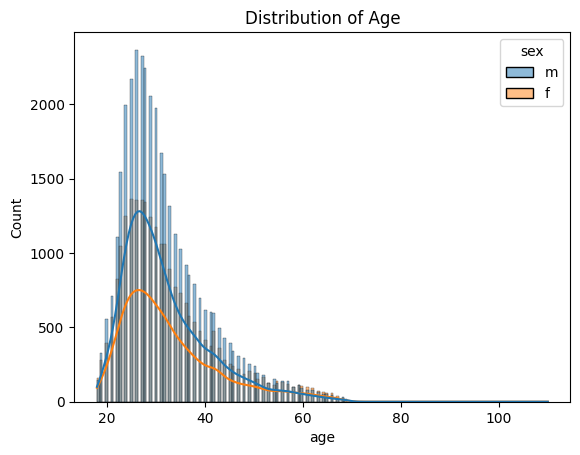

In [31]:
sns.histplot(data=cupid_signs, x='age', hue='sex', kde=True)
plt.title('Distribution of Age')
plt.show()

### Text Vectorization

In [32]:
# consulted geeksforgeeks.org 
# https://www.geeksforgeeks.org/python/python-lemmatization-with-nltk/
def lemmatize_sentence(sentence):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(sentence)
    lemmatized_tokens = [lemmatizer.lemmatize(token)+' ' for token in tokens]
    return ''.join(lemmatized_tokens)

In [33]:
cupid_signs['essayLemmatized'] = cupid_signs['essay'].apply(lemmatize_sentence)

In [34]:
min_ngram = 1
max_ngram = 3
stop_words = 'english'
vectorizer = 15

okcupid_essays = cupid_signs

tfidf_vectorizer = TfidfVectorizer(
    max_features=vectorizer,
    stop_words=stop_words,
    ngram_range=(min_ngram,max_ngram)
    )


In [35]:
tfidf_model = tfidf_vectorizer.fit_transform(okcupid_essays['essayLemmatized'])
tfidf_text = tfidf_vectorizer.get_feature_names_out()
tfidf_stop_words_vect = tfidf_vectorizer.get_stop_words()
tfidf_columns_text = ["Tfidf Score: "+ item for item in tfidf_text]

tfidf_words_df = pd.DataFrame(
    tfidf_model.toarray(),
    columns=tfidf_text)

essay_final = okcupid_essays.join(tfidf_words_df).fillna('')

In [36]:
count_vectorizer = CountVectorizer(
    max_features=vectorizer,
    stop_words=stop_words,
    ngram_range=(min_ngram,max_ngram)
    )

count_model = count_vectorizer.fit_transform(okcupid_essays['essayLemmatized'])
count_text = count_vectorizer.get_feature_names_out()
count_stop_words_vect = count_vectorizer.get_stop_words()
count_columns_text = ["Word Count: "+ item for item in count_text]

count_words_df = pd.DataFrame(
    count_model.toarray(),
    columns=count_columns_text)

essay_final = essay_final.join(count_words_df).fillna('')

In [37]:
tfidf_words_df.head()

,book,food,friend,good,just,life,like,love,movie,music,new,people,really,thing,time
0,0.395206,0.245113,0.112799,0.360734,0.132414,0.251870,0.109226,0.458110,0.123916,0.116274,0.139261,0.126106,0.442132,0.252057,0.122179
1,0.000000,0.165252,0.000000,0.162134,0.357086,0.169807,0.000000,0.617701,0.000000,0.156781,0.375549,0.170037,0.397438,0.169933,0.164743
2,0.091525,0.085148,0.470214,0.083542,0.183994,0.000000,0.607092,0.079570,0.086093,0.161568,0.290261,0.438071,0.000000,0.175121,0.084886
3,0.594271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.568875,0.000000,0.568527,0.000000
4,0.343130,0.319222,0.587612,0.000000,0.000000,0.328022,0.000000,0.000000,0.322763,0.302859,0.362731,0.000000,0.000000,0.000000,0.000000


In [38]:
count_words_df.head()

,Word Count: book,Word Count: food,Word Count: friend,Word Count: good,Word Count: just,Word Count: life,Word Count: like,Word Count: love,Word Count: movie,Word Count: music,Word Count: new,Word Count: people,Word Count: really,Word Count: thing,Word Count: time
0,3,2,1,3,1,2,1,4,1,1,1,1,3,2,1
1,0,1,0,1,2,1,0,4,0,1,2,1,2,1,1
2,1,1,6,1,2,0,8,1,1,2,3,5,0,2,1
3,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,1,1,2,0,0,1,0,0,1,1,1,0,0,0,0


In [39]:
features = ['age', 'height', 'book', 'food', 'friend',
            'movie', 'music', 'life',
            'new', 'people',
            'thing', 'time',
            'Word Count: book', 'Word Count: food',
            'Word Count: friend',
            'Word Count: life',
            'Word Count: movie', 'Word Count: music',
            'Word Count: new', 'Word Count: people',
            'Word Count: thing', 'Word Count: time',
            'sex', 'orientation', 'body_type',
            'smokes', 'drinks', 'drugs', 
            'graduated from', 'working on', 'dropped out',
            'college/university', 'masters', 'two-year college',
            'high school', 'ph.d', 'law school', 'space camp',
            'med school',
            'agnosticism',
            'islam', 'hinduism', 'judaism', 'atheism', 'christianity',
            'other religion', 'buddhism', 'catholicism',
            'religion not too serious', 'laughing about religion',
            'religion somewhat serious', 'religion very serious',
            'white', 'black', 'asian', 'hispanic / latin',
            'middle eastern', 'indian', 'pacific islander',
            'native american', 'other ethnicity']

X = essay_final[features[0:22]].copy()
X.head()

,age,height,book,food,friend,movie,music,life,new,people,...,Word Count: book,Word Count: food,Word Count: friend,Word Count: life,Word Count: movie,Word Count: music,Word Count: new,Word Count: people,Word Count: thing,Word Count: time
0,22,75.0,0.395206,0.245113,0.112799,0.123916,0.116274,0.251870,0.139261,0.126106,...,3,2,1,2,1,1,1,1,2,1
1,35,70.0,0.000000,0.165252,0.000000,0.000000,0.156781,0.169807,0.375549,0.170037,...,0,1,0,1,0,1,2,1,1,1
2,38,68.0,0.091525,0.085148,0.470214,0.086093,0.161568,0.000000,0.290261,0.438071,...,1,1,6,0,1,2,3,5,2,1
3,23,71.0,0.594271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.568875,...,1,0,0,0,0,0,0,1,1,0
4,29,66.0,0.343130,0.319222,0.587612,0.322763,0.302859,0.328022,0.362731,0.000000,...,1,1,2,1,1,1,1,0,0,0


In [40]:
for feat in features[22:]:
    X[feat] = pd.Categorical(cupid_signs[feat])
    X[feat] = X[feat].cat.codes

scaler = StandardScaler()
scaler.set_output(transform='pandas')

X_scaled = scaler.fit_transform(X)

In [41]:
num_clusters=list(np.arange(1, 21)) # bigger numbers higher chance of crash

inertias = []

for k in num_clusters:
  model = KMeans(n_clusters = k, n_init='auto')
  model.fit(X_scaled)
  inertias.append(model.inertia_)

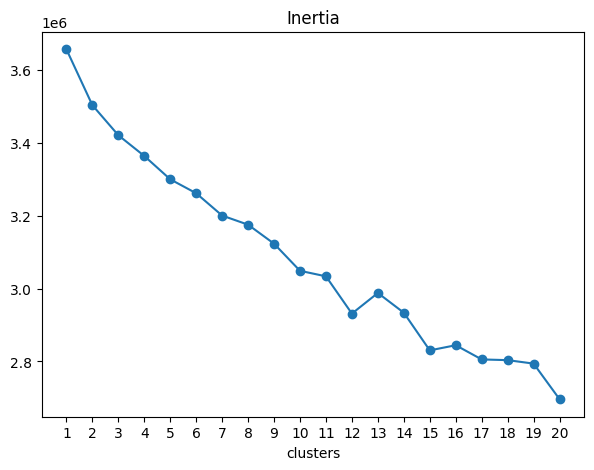

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(num_clusters, inertias, '-o')
ax.set(xticks=num_clusters, xlabel='clusters', title='Inertia')
plt.show()

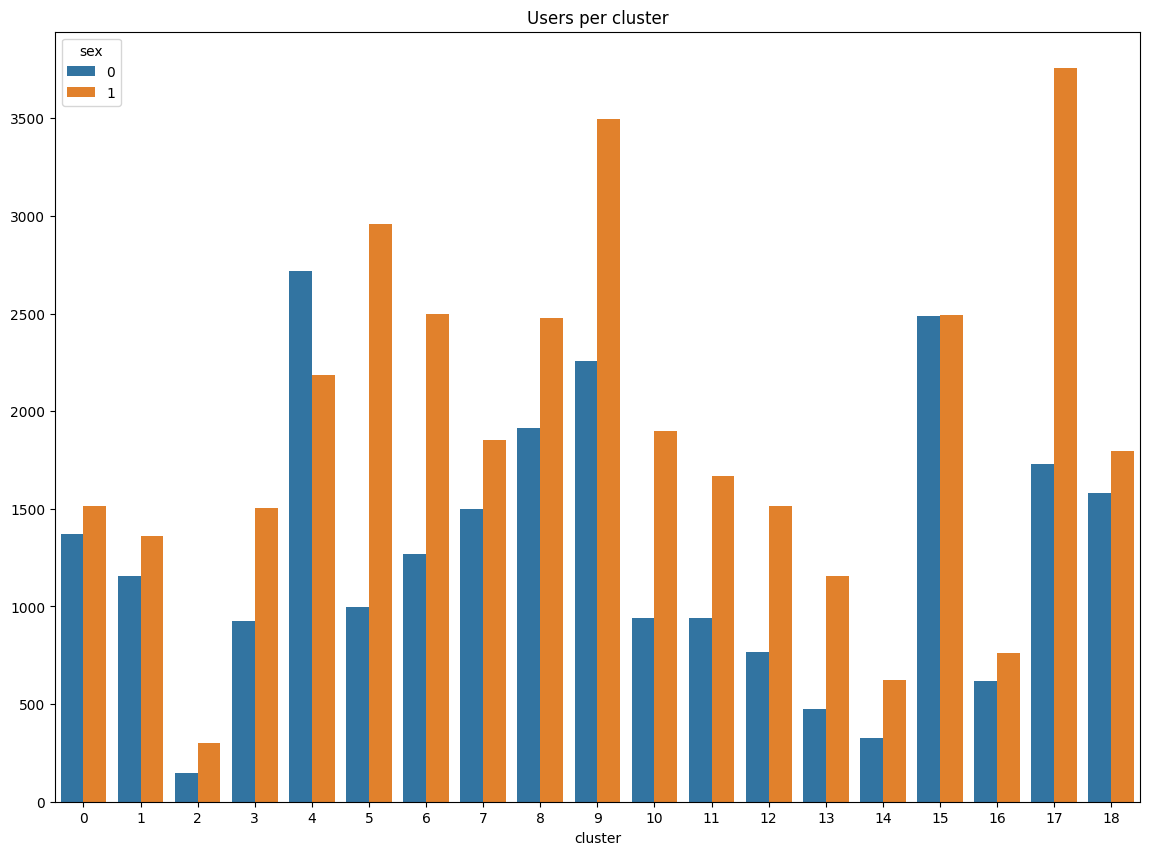

In [43]:
k = 19
model = KMeans(n_clusters = k, n_init='auto', random_state=42)
model.fit(X_scaled)
X['cluster'] = model.labels_
X.cluster.value_counts()

fig2, ax2 = plt.subplots(figsize=(14, 10))

sns.countplot(data=X, x='cluster', ax=ax2, hue='sex')
ax2.set(title = 'Users per cluster', ylabel='')
plt.show()

In [44]:
tsne_cluster = TSNE(n_components=2, random_state=42)
tsne_cluster_result = tsne_cluster.fit_transform(X) # very long runtime

tsne_cluster_result

array([[-34.397377 , -64.399796 ],
       [ 24.336514 ,  22.682339 ],
       [-68.37425  ,   2.7715435],
       ...,
       [ 37.174564 ,  12.197755 ],
       [-26.112478 , -76.642006 ],
       [ 37.25667  ,  59.536396 ]], shape=(59946, 2), dtype=float32)

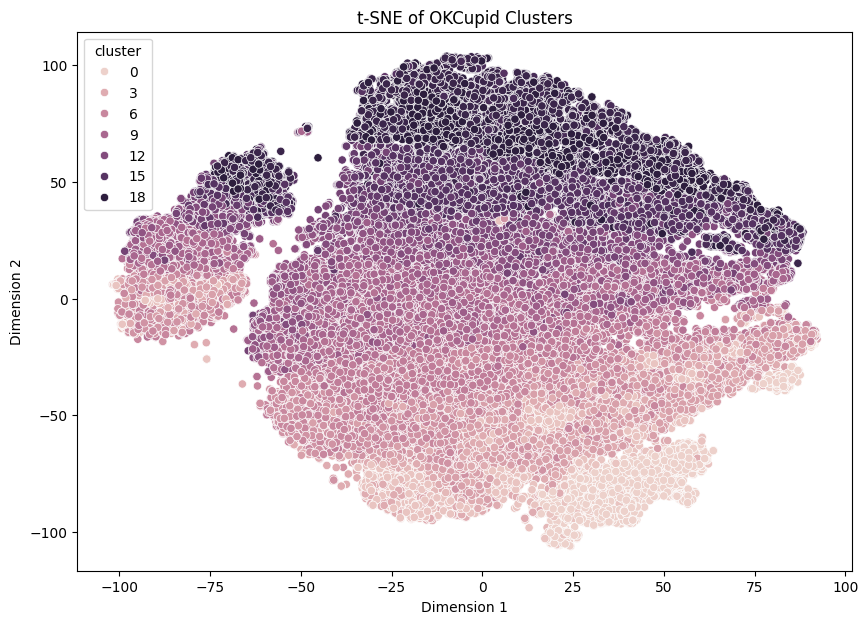

In [45]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result[:, 0], y=tsne_cluster_result[:, 1], hue=X['cluster'])

plt.title('t-SNE of OKCupid Clusters')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

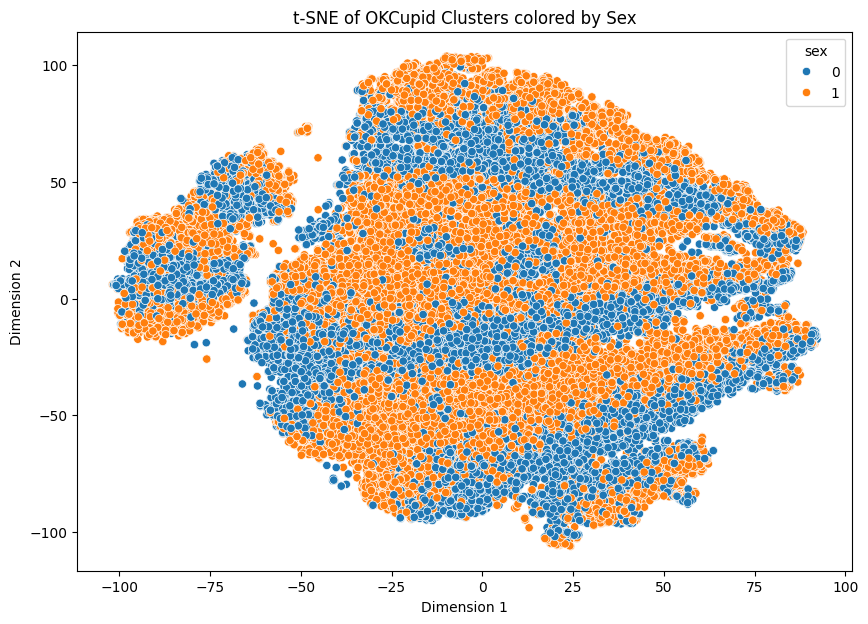

In [46]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result[:, 0], y=tsne_cluster_result[:, 1], hue=X['sex'])

plt.title('t-SNE of OKCupid Clusters colored by Sex')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [47]:
X_nonwhite = X[X.white == 0]

tsne_cluster_result_nonwhite = tsne_cluster.fit_transform(X_nonwhite)

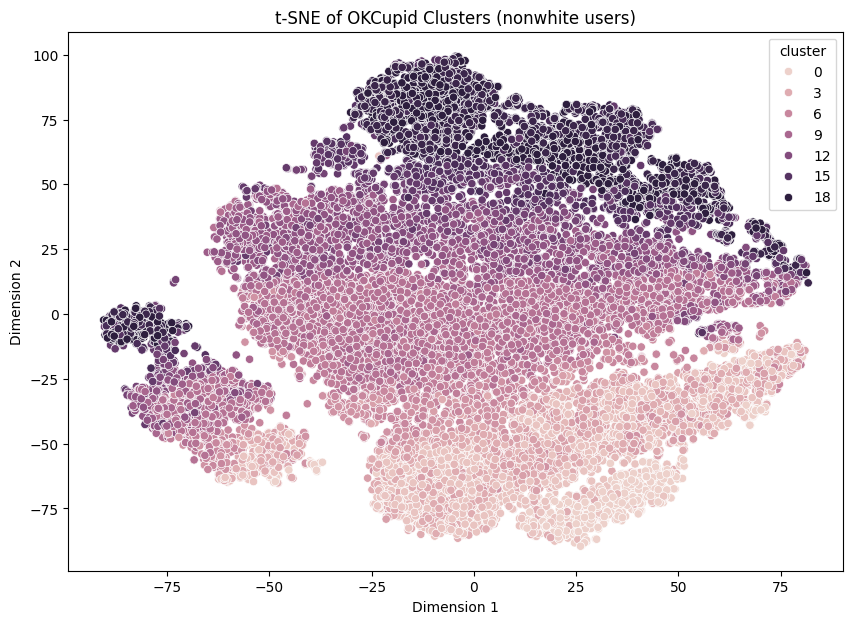

In [48]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result_nonwhite[:, 0], y=tsne_cluster_result_nonwhite[:, 1], hue=X_nonwhite['cluster'])

plt.title('t-SNE of OKCupid Clusters (nonwhite users)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

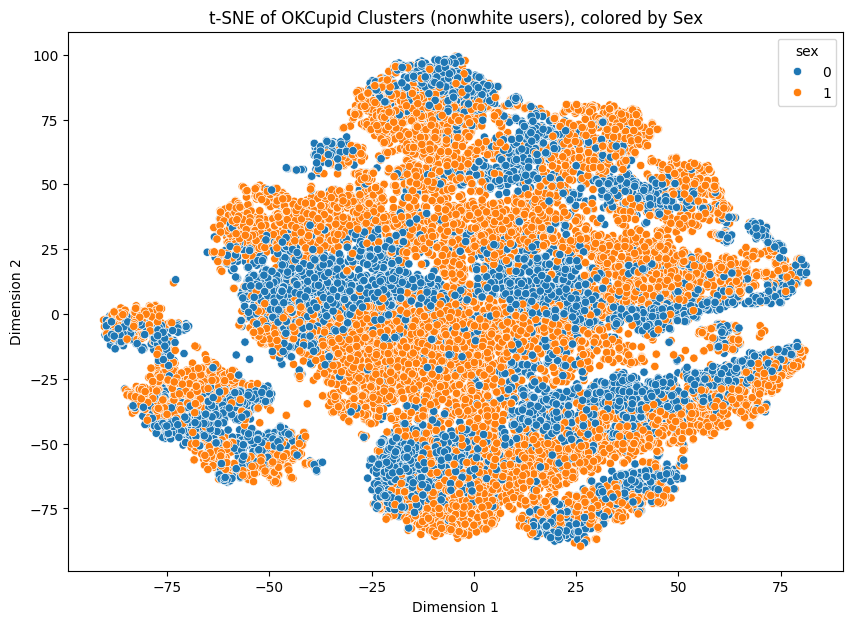

In [49]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result_nonwhite[:, 0], y=tsne_cluster_result_nonwhite[:, 1], hue=X_nonwhite['sex'])

plt.title('t-SNE of OKCupid Clusters (nonwhite users), colored by Sex')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [50]:
X_white = X[X.white == 1]

tsne_cluster_result_white = tsne_cluster.fit_transform(X_white)

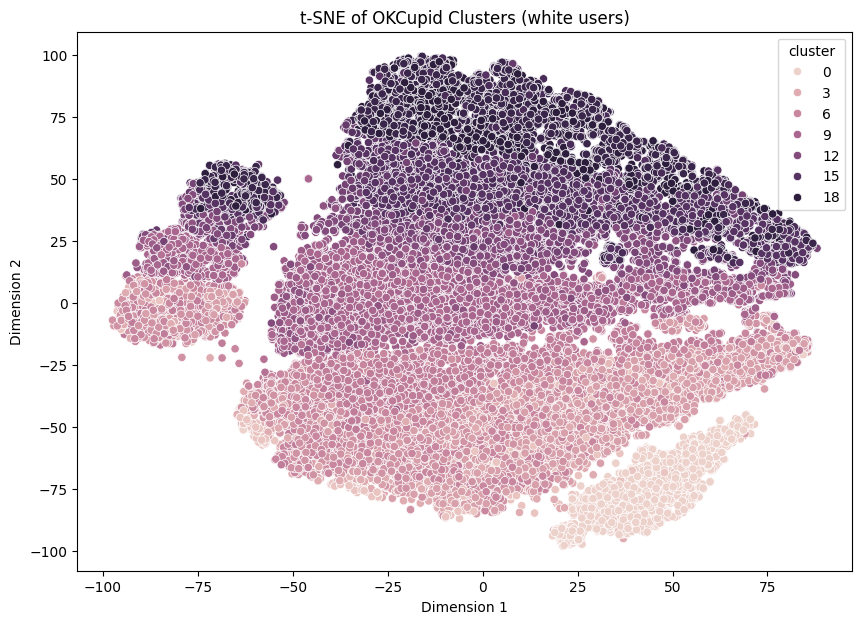

In [51]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result_white[:, 0], y=tsne_cluster_result_white[:, 1], hue=X_white['cluster'])

plt.title('t-SNE of OKCupid Clusters (white users)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

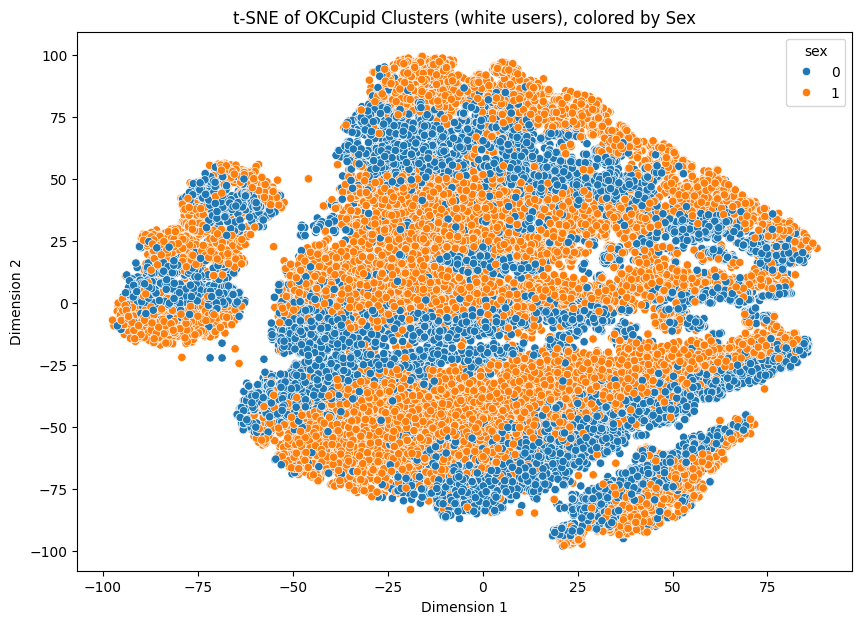

In [52]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_cluster_result_white[:, 0], y=tsne_cluster_result_white[:, 1], hue=X_white['sex'])

plt.title('t-SNE of OKCupid Clusters (white users), colored by Sex')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [53]:
X[X.cluster == 0].describe()

,age,height,book,food,friend,movie,music,life,new,people,...,white,black,asian,hispanic / latin,middle eastern,indian,pacific islander,native american,other ethnicity,cluster
count,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,...,2889.000000,2889.00000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.000000,2889.0
mean,34.105227,67.936656,0.141361,0.145889,0.185022,0.146340,0.172602,0.238351,0.163946,0.290898,...,0.759086,0.03046,0.095881,0.062998,0.000692,0.011423,0.014538,0.024922,0.040498,0.0
std,9.492635,3.895155,0.109609,0.109108,0.118761,0.108133,0.123613,0.151893,0.122816,0.157363,...,0.427712,0.17188,0.294479,0.243001,0.026307,0.106283,0.119714,0.155915,0.197159,0.0
min,18.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,27.000000,65.000000,0.064558,0.065585,0.097507,0.067750,0.074228,0.125451,0.070782,0.176847,...,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,32.000000,68.000000,0.122303,0.125063,0.168331,0.125321,0.146139,0.219564,0.144519,0.275231,...,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,39.000000,71.000000,0.198035,0.207202,0.257119,0.205964,0.241227,0.324776,0.241188,0.388373,...,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,69.000000,80.000000,0.763122,0.634758,0.726774,0.628690,0.752876,0.890589,0.730026,0.884464,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [54]:
X_white.cluster.value_counts()

cluster
9     4770
15    4302
4     4100
17    3396
5     3327
6     3259
7     2568
0     2193
18    1898
10    1710
12    1598
13    1068
16     947
3      770
11     767
14     490
1      457
8      233
2       29
Name: count, dtype: int64

In [55]:
X_nonwhite.cluster.value_counts()

cluster
8     4159
17    2091
1     2061
11    1844
3     1661
18    1482
10    1130
9      981
4      803
7      782
0      696
12     684
15     679
5      631
13     562
6      508
14     456
16     434
2      420
Name: count, dtype: int64

In [56]:
X[X.asian == 1].cluster.value_counts()

cluster
8     4365
18     611
17     577
10     296
5      289
0      277
12     271
7      265
3      213
16     177
6      174
13     170
14     138
1       95
11      86
9       77
4       56
15      38
2       30
Name: count, dtype: int64

In [57]:
X[X.black == 1].cluster.value_counts()

cluster
1     2518
10     309
14     112
0       88
13      76
16      70
12      59
3       43
18      22
7       15
5        6
2        6
6        2
4        1
8        1
Name: count, dtype: int64

In [58]:
X[X['hispanic / latin'] == 1].cluster.value_counts()

cluster
11    2611
18     798
10     477
3      271
1      190
0      182
14     167
13     147
5       96
12      93
7       78
6       69
16      59
4       59
17      21
8       11
15      11
9       11
2        6
Name: count, dtype: int64

In [59]:
X[X['middle eastern'] == 1].cluster.value_counts()

cluster
14    946
2       2
0       2
Name: count, dtype: int64

In [60]:
X[X['other ethnicity'] == 1].cluster.value_counts()

cluster
3     2431
10     214
13     197
1      195
14     172
0      117
12      99
16      58
18      37
2       20
7       20
5        5
17       1
4        1
Name: count, dtype: int64

In [61]:
essay_sum = pd.DataFrame(tfidf_words_df.sum(), columns=['sum'])
essay_sum.reset_index(inplace=True)
essay_sum.rename(columns={'index':'word'}, inplace=True)

top50_essay = essay_sum.sort_values(by='sum', ascending=False)[:50]

top50_essay

,word,sum
6,like,14819.099537
7,love,13794.162800
2,friend,11659.277078
3,good,10811.115939
9,music,10477.448058
14,time,10112.373652
5,life,9918.427778
13,thing,9901.955396
11,people,9821.406046
1,food,8985.250161
